# Does a background correction explain disk's weak averaging gain?

Follow-up on `test_bead_round_averaging.ipynb`
(`prompt_history/2026_09_02_1805_corner_vs_diagonal_residuals_and_bead_
averaging.md`): averaging aligned beads frames across rounds cut background
noise std to only 1.12x for `epi` (vs. the 3.16x `sqrt(10)` independent-noise
rounds would predict) and to 0.95x for `disk` -- **no improvement at all**
(vs. `sqrt(2)`=1.41x), with disk's own zoomed comparison figure showing a
visible fixed-pattern vertical striping/gradient in the background that
doesn't average out because it's identical in every round.

This notebook tests two corrections against that hypothesis:

1. **Local background subtraction** -- each frame minus its own heavily
   Gaussian-smoothed copy. Self-contained (one FOV, no other-FOV reads), but
   can only remove structure much coarser than its smoothing sigma.
2. **Multi-FOV flat-field correction (FFC)** -- `MERci.analysis.ffc`'s own
   illumination-field estimator, computed from **all** FOVs of the cells
   round (476 for `epi`, 603 for `disk`), the same technique already used
   for round mosaics elsewhere in this repo. Averaging over hundreds of FOVs
   should isolate the microscope's actual fixed vignetting field from any
   one FOV's own real bead/tissue signal, in principle correcting finer
   structure than option 1 can reach.

**Characterized first, not assumed** (Section 4): FFT of the row-mean and
column-mean profiles of each dataset's own round-1 beads frame.
`disk`'s frame has a low mean/std (103 / 6.9 -- close to the camera's dark
level, i.e. genuinely low bead signal) and its column-mean profile is
dominated by a single smooth, low-frequency gradient (period on the order of
the full frame, not fine per-line banding), with the modulation a large
fraction (~28%) of the frame's own mean. `epi`'s frame has a far higher
mean/std (5637 / 8065) where the dominant row/column-mean structure is real
bead signal, not a background gradient. This is why the hypothesis expects a
correction to matter for `disk` but not `epi` -- confirmed or refuted with
real numbers in Section 8, not assumed from the characterization alone.

**Prior result, local background subtraction alone (kept for context, not
re-derived)**: `epi` unaffected (1.122x -> 1.121x, as predicted); `disk`
improved but only partially (0.954x -> 1.025x, still well short of 1.414x)
-- the coarse gradient was removed cleanly, but a finer vertical striping
pattern, too fine for that correction's smoothing scale, persisted and
stayed round-invariant. This notebook adds the multi-FOV FFC pipeline to
check whether it reaches further into that residual structure.

Reuses `test_bead_round_averaging.ipynb`'s own dataset-resolution,
FiducialCorrelationWarp-offset mapping, and round1-vs-average pipeline
(kept self-contained here, same convention as that notebook relative to
`test_stitching.ipynb`), with both correction steps applied to each round's
raw beads frame before alignment (both are fixed properties of the
camera/optics in camera-pixel coordinates, not the sample, and the per-round
alignment shift is at most a few px -- verified in
`test_bead_round_averaging.ipynb` -- so applying either correction before or
after the shift makes negligible difference here).

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import shift as ndi_shift, gaussian_filter

MERCI_DIR = Path(os.getcwd()).parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import load_positions, read_image_frames
from MERci.common.experiment_info import load_experiment_info, resolve_sample_identity, positions_file_tag
from MERci.acquisition.configs    import get_camera_pixel_size_um
from MERci.acquisition.alignment  import remove_hot_pixels, phase_drift
from MERci.analysis.ffc           import compute_ffc_field_for_color, apply_ffc, save_ffc_field, load_ffc_field

NOTEBOOK_NAME = "test_bead_background_correction"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci


## 2 — Parameters

In [2]:
# Same two real BC555_sample_05 datasets as test_bead_round_averaging.ipynb.
DATASETS = [
    ("epi",  "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi"),
    ("disk", "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk"),
]

IMAGE_SUFFIX = ".zarr"
BEAD_FRAME_INDEX = 0
ROUND_TYPES_TO_USE = ("cells", "bits")

# Local-background estimate = a heavily Gaussian-smoothed copy of the frame
# itself. sigma_px=50 matches MERci.analysis.ffc.compute_ffc_field_for_color's
# own default smooth_sigma_px -- same repo convention for "large enough to
# average out bead spots (a few px), small enough to still track a
# few-hundred-px-scale gradient". The FFC field below reuses this same
# default via compute_ffc_field_for_color's own defaults, so both
# corrections share the same smoothing scale.
BG_SIGMA_PX = 50.0

FORCE_RECOMPUTE = False

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10

print(f"Datasets to analyze: {[label for label, _ in DATASETS]}  |  BG_SIGMA_PX={BG_SIGMA_PX}")

Datasets to analyze: ['epi', 'disk']  |  BG_SIGMA_PX=50.0


## 3 — Resolve dataset geometry + pick one representative FOV

Identical to `test_bead_round_averaging.ipynb` Section 3.

In [3]:
def resolve_dataset_geometry(dataset_label, dataset_dir):
    sample_dir = Path(dataset_dir)
    sample_name, imaging_dir = resolve_sample_identity(sample_dir / "MERci")
    positions_tag = positions_file_tag(sample_name, imaging_dir)

    info       = load_experiment_info(sample_dir / "metadata" / "experiment_info.yaml")
    microscope = info.microscope

    config = ExperimentConfig(
        data_dir       = sample_dir / "data",
        metadata_dir   = sample_dir / "metadata",
        analysis_dir   = sample_dir / "analysis",
        settings_dir   = sample_dir / "settings",
        round_info_csv = sample_dir / "metadata" / "round_info.csv",
        positions_txt  = sample_dir / "positions" / f"positions_{positions_tag}.txt",
        image_suffix   = IMAGE_SUFFIX,
        microscope     = microscope,
    )
    meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                    image_suffix=config.image_suffix)

    full_positions = load_positions(config.positions_txt)
    pixel_size_um  = get_camera_pixel_size_um(microscope)

    round_ids = []
    for rid in meta.valid_round_ids():
        series = meta.series_for_round(rid)
        if series and (series[0].imaging_type or "").strip().lower() in ROUND_TYPES_TO_USE:
            round_ids.append(rid)
    round_ids.sort()
    cells_round_id = next(rid for rid in round_ids
                           if meta.series_for_round(rid)[0].imaging_type.strip().lower() == "cells")
    bits_round_ids = [rid for rid in round_ids if rid != cells_round_id]

    cells_fov_ids = sorted(meta.fovs)
    coords_arr = np.array([full_positions[f] for f in cells_fov_ids], dtype=float)
    centroid   = coords_arr.mean(axis=0)
    dist       = np.hypot(coords_arr[:, 0] - centroid[0], coords_arr[:, 1] - centroid[1])
    for fov_id in [cells_fov_ids[i] for i in np.argsort(dist)]:
        if all(meta.series_for_round(rid)[0].resolve_path(fov_id, config.image_suffix).exists()
               for rid in round_ids):
            representative_fov = fov_id
            break
    else:
        raise RuntimeError(f"[{dataset_label}] No FOV has on-disk data for every round in {round_ids}")

    figures_dir = config.analysis_dir / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    print(f"[{dataset_label}] SAMPLE_DIR        : {sample_dir}")
    print(f"[{dataset_label}] MICROSCOPE        : {microscope}")
    print(f"[{dataset_label}] Rounds used       : {round_ids}  (cells={cells_round_id}, bits={bits_round_ids})")
    print(f"[{dataset_label}] Representative FOV: {representative_fov}  (closest-to-centroid with full data)")
    print(f"[{dataset_label}] Total FOVs (cells round): {len(cells_fov_ids)}")

    return {
        "dataset_label": dataset_label, "sample_dir": sample_dir, "sample_name": sample_name,
        "microscope": microscope, "config": config, "meta": meta,
        "pixel_size_um": pixel_size_um, "cells_round_id": cells_round_id, "bits_round_ids": bits_round_ids,
        "round_ids": round_ids, "representative_fov": representative_fov, "figures_dir": figures_dir,
        "all_fov_ids": cells_fov_ids,
    }

## 4 — Characterize the background: is it a smooth gradient?

Row-mean and column-mean profiles of round 1's own beads frame, plus an FFT
of each profile to find the dominant spatial period. A slow, few-cycle
period (large fraction of the frame width) is consistent with an
illumination/vignette gradient; a period of a few px would instead point to
per-line sensor/readout banding, which a large-sigma blur would NOT
correctly model as background.

In [4]:
def characterize_background(dataset_geo):
    label, meta, config = dataset_geo["dataset_label"], dataset_geo["meta"], dataset_geo["config"]
    fov_id, cells_round_id = dataset_geo["representative_fov"], dataset_geo["cells_round_id"]
    series = meta.series_for_round(cells_round_id)[0]
    path = series.resolve_path(fov_id, config.image_suffix)
    frame = read_image_frames(path, [BEAD_FRAME_INDEX],
                               frame_width=config.frame_width, frame_height=config.frame_height)[0].astype(float)

    row_mean, col_mean = frame.mean(axis=1), frame.mean(axis=0)

    def top_period(profile):
        detrended = profile - profile.mean()
        fft = np.abs(np.fft.rfft(detrended))
        freqs = np.fft.rfftfreq(len(detrended))
        i = np.argmax(fft[1:]) + 1   # skip DC
        return (1 / freqs[i]) if freqs[i] > 0 else np.inf

    print(f"[{label}] frame mean={frame.mean():.1f}  std={frame.std():.1f}")
    print(f"[{label}] row_mean range=({row_mean.min():.1f},{row_mean.max():.1f})"
          f"  dominant period={top_period(row_mean):.0f} px  (frame height={frame.shape[0]})")
    print(f"[{label}] col_mean range=({col_mean.min():.1f},{col_mean.max():.1f})"
          f"  dominant period={top_period(col_mean):.0f} px  (frame width={frame.shape[1]})")
    return frame, row_mean, col_mean

[epi] SAMPLE_DIR        : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi
[epi] MICROSCOPE        : MF3
[epi] Rounds used       : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (cells=1, bits=[2, 3, 4, 5, 6, 7, 8, 9, 10])
[epi] Representative FOV: 221  (closest-to-centroid with full data)
[epi] Total FOVs (cells round): 476


[epi] frame mean=5636.6  std=8064.5
[epi] row_mean range=(3306.7,8062.9)  dominant period=2048 px  (frame height=2048)
[epi] col_mean range=(1728.3,9763.9)  dominant period=2048 px  (frame width=2048)
[disk] SAMPLE_DIR        : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk
[disk] MICROSCOPE        : ST2
[disk] Rounds used       : [1, 2]  (cells=1, bits=[2])
[disk] Representative FOV: 301  (closest-to-centroid with full data)
[disk] Total FOVs (cells round): 603


[disk] frame mean=103.4  std=6.9
[disk] row_mean range=(100.4,109.1)  dominant period=2304 px  (frame height=2304)
[disk] col_mean range=(93.9,123.1)  dominant period=1152 px  (frame width=2304)


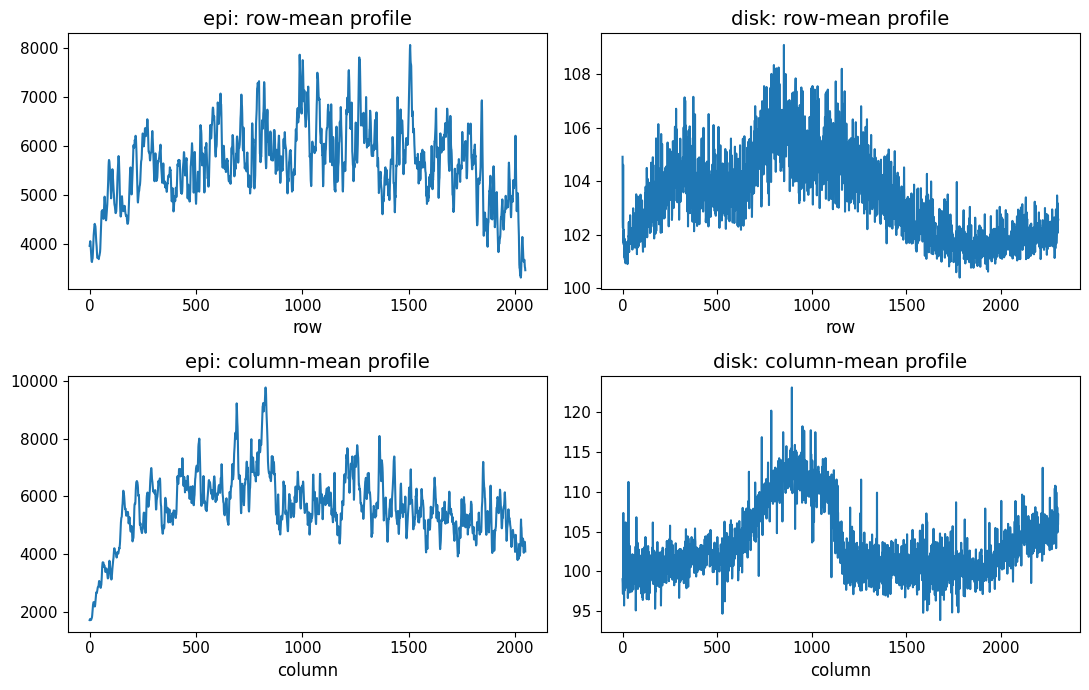

Saved: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/test_bead_background_correction_comparison/test_bead_background_correction.background_profiles.png


In [5]:
BG_CHARACTERIZATION = {}
for dataset_label, dataset_dir in DATASETS:
    dataset_geo = resolve_dataset_geometry(dataset_label, dataset_dir)
    frame, row_mean, col_mean = characterize_background(dataset_geo)
    BG_CHARACTERIZATION[dataset_label] = {
        "dataset_geo": dataset_geo, "frame": frame, "row_mean": row_mean, "col_mean": col_mean,
    }

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for col, (dataset_label, C) in enumerate(BG_CHARACTERIZATION.items()):
    axes[0, col].plot(C["row_mean"])
    axes[0, col].set_title(f"{dataset_label}: row-mean profile", fontsize=PLOT_TITLE_FONTSIZE)
    axes[0, col].set_xlabel("row", fontsize=PLOT_LABEL_FONTSIZE)
    axes[1, col].plot(C["col_mean"])
    axes[1, col].set_title(f"{dataset_label}: column-mean profile", fontsize=PLOT_TITLE_FONTSIZE)
    axes[1, col].set_xlabel("column", fontsize=PLOT_LABEL_FONTSIZE)
    for ax in (axes[0, col], axes[1, col]):
        ax.tick_params(axis="both", labelsize=PLOT_TICK_FONTSIZE)
fig.tight_layout()
fig_path = MERCI_DIR / "cache" / "test_bead_background_correction_comparison" / f"{NOTEBOOK_NAME}.background_profiles.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")

## 5 — Multi-FOV flat-field correction (FFC), computed from ALL FOVs

`MERci.analysis.ffc.compute_ffc_field_for_color` accumulates a running mean
over every sample, Gaussian-smooths it (`smooth_sigma_px=50.0` by default,
same scale as the local correction above), then normalizes to ~1.0 peak --
its own docstring's `"single_fov_all_frames"`/`"exterior_grid"`/
`"emptiest_stats"` strategies are for *online*, mid-acquisition use when
not every FOV is available yet; here, post-hoc with the full dataset on
disk, we use literally **every** FOV of the cells round (one sample per FOV,
`BEAD_FRAME_INDEX`) -- 476 for `epi`, 603 for `disk` -- so real bead/tissue
signal, which varies per FOV, averages out far more thoroughly than any
FOV-subset strategy, leaving a cleaner estimate of the vignetting each pixel
location experiences regardless of FOV.

One field per dataset, computed once from the cells round and reused for
every round's beads frame -- vignetting is a fixed property of the
microscope/channel, not of round (`ffc.py`'s own stated assumption).
Cached (`~2-3 min` to compute per dataset from ~500 FOV reads;
`~/analysis/cache/test_bead_background_correction/ffc_field.npz`).

[epi] Computing FFC field from 476 FOVs (cells round 1)...


[epi] FFC field computed from 476 FOVs and cached: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_bead_background_correction/ffc_field.npz
[disk] Computing FFC field from 603 FOVs (cells round 1)...


[disk] FFC field computed from 603 FOVs and cached: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_background_correction/ffc_field.npz


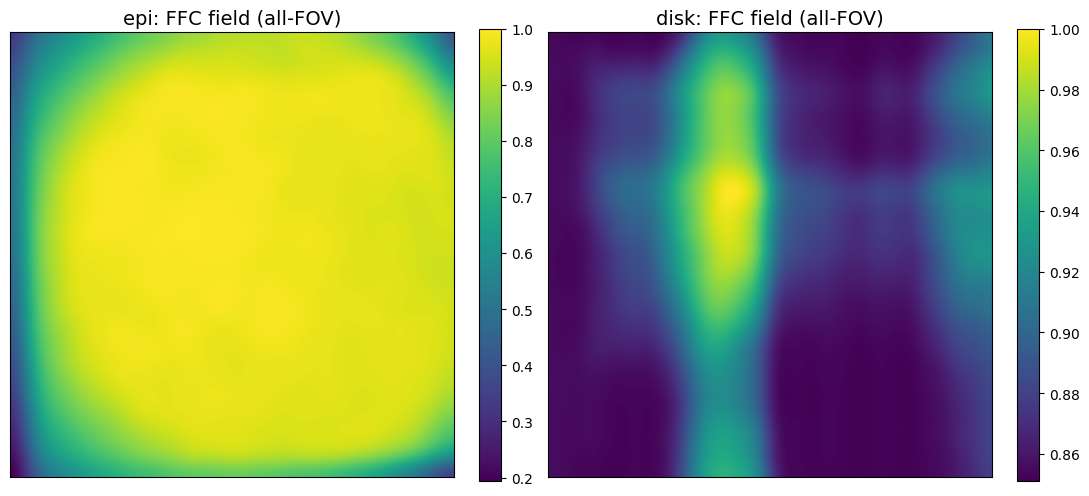

Saved: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/test_bead_background_correction_comparison/test_bead_background_correction.ffc_fields.png


In [6]:
def compute_dataset_ffc_field(dataset_geo):
    label, config, meta = dataset_geo["dataset_label"], dataset_geo["config"], dataset_geo["meta"]
    cache_path = config.analysis_dir / "cache" / NOTEBOOK_NAME / "ffc_field.npz"

    if not FORCE_RECOMPUTE and cache_path.exists():
        field, field_meta = load_ffc_field(cache_path)
        print(f"[{label}] Loaded cached FFC field ({int(field_meta.get('n_samples', -1))} samples): {cache_path}")
        return field

    cells_round_id = dataset_geo["cells_round_id"]
    series = meta.series_for_round(cells_round_id)[0]
    samples = [(series.resolve_path(fov_id, config.image_suffix), BEAD_FRAME_INDEX)
               for fov_id in dataset_geo["all_fov_ids"]
               if series.resolve_path(fov_id, config.image_suffix).exists()]

    print(f"[{label}] Computing FFC field from {len(samples)} FOVs (cells round {cells_round_id})...")
    field, field_meta = compute_ffc_field_for_color(samples, dataset_geo["config"].frame_width,
                                                      dataset_geo["config"].frame_height)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    save_ffc_field(cache_path, field, {**field_meta, "round_id": cells_round_id})
    print(f"[{label}] FFC field computed from {field_meta['n_samples']} FOVs and cached: {cache_path}")
    return field


FFC_FIELDS = {}
for dataset_label, C in BG_CHARACTERIZATION.items():
    FFC_FIELDS[dataset_label] = compute_dataset_ffc_field(C["dataset_geo"])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (dataset_label, field) in zip(axes, FFC_FIELDS.items()):
    im = ax.imshow(field, cmap="viridis")
    ax.set_title(f"{dataset_label}: FFC field (all-FOV)", fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig_path = MERCI_DIR / "cache" / "test_bead_background_correction_comparison" / f"{NOTEBOOK_NAME}.ffc_fields.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")

## 6 — Map each round to its MERlin offset row, load + align + correct

Same offset-row mapping and empirically-verified `relative_shift_to_cells`
formula as `test_bead_round_averaging.ipynb` Sections 4-5 (see that
notebook's own docstring for the verification this formula is based on --
not re-derived here). Both corrections are applied to each round's RAW beads
frame, before alignment, for the reason given in Section 1's intro.

Three pipelines run in parallel per dataset -- `raw`, `bg_corrected` (local,
Section 1's option 1), `ffc_corrected` (multi-FOV, Section 5) -- so
Section 8 can compare round1-vs-average under all three.

In [7]:
def resolve_round_offset_rows(dataset_geo):
    sample_dir = dataset_geo["sample_dir"]
    dataorg_csvs = sorted((sample_dir / "merlin" / "dataorganization").glob("*.csv"))
    if len(dataorg_csvs) != 1:
        raise RuntimeError(f"Expected exactly 1 data-organization CSV, found {dataorg_csvs}")
    dataorg = pd.read_csv(dataorg_csvs[0])

    dapi_rows = dataorg.index[dataorg["channelName"] == "DAPI"].tolist()
    if len(dapi_rows) != 1:
        raise RuntimeError(f"Expected exactly 1 DAPI row in {dataorg_csvs[0]}, found {len(dapi_rows)}")
    cells_row = int(dapi_rows[0])

    bits_dataorg = dataorg[dataorg["channelName"] != "DAPI"]
    bits_rows_by_round = (bits_dataorg.groupby("imagingRound").apply(lambda g: int(g.index[0]))
                                        .sort_index().tolist())

    bits_round_ids = sorted(dataset_geo["bits_round_ids"])
    if len(bits_rows_by_round) != len(bits_round_ids):
        raise RuntimeError(
            f"[{dataset_geo['dataset_label']}] {len(bits_rows_by_round)} distinct bits imagingRound groups "
            f"in {dataorg_csvs[0]} != {len(bits_round_ids)} bits rounds in round_info.csv."
        )

    round_offset_row = {dataset_geo["cells_round_id"]: cells_row}
    round_offset_row.update(dict(zip(bits_round_ids, bits_rows_by_round)))
    return round_offset_row


def subtract_local_background(frame, sigma_px=BG_SIGMA_PX):
    """Subtract a heavily Gaussian-smoothed copy of *frame* from itself,
    adding the smoothed field's own mean back so the corrected frame stays
    on the same intensity scale (flattens the spatial gradient, doesn't
    change the overall brightness level)."""
    bg = gaussian_filter(frame.astype(float), sigma=sigma_px)
    return frame.astype(float) - bg + bg.mean()


PIPELINE_NAMES = ("raw", "bg_corrected", "ffc_corrected")


def load_align_pipelines(dataset_geo, round_offset_row, ffc_field):
    label   = dataset_geo["dataset_label"]
    meta    = dataset_geo["meta"]
    config  = dataset_geo["config"]
    fov_id  = dataset_geo["representative_fov"]
    cells_round_id = dataset_geo["cells_round_id"]

    offsets_path = (dataset_geo["sample_dir"] / "merlin" / "output" / "FiducialCorrelationWarp"
                     / "transformations" / f"offsets_{fov_id}.npy")
    offsets = np.load(offsets_path, allow_pickle=True)

    def load_beads(round_id):
        series = meta.series_for_round(round_id)[0]
        path   = series.resolve_path(fov_id, config.image_suffix)
        return read_image_frames(path, [BEAD_FRAME_INDEX],
                                  frame_width=config.frame_width, frame_height=config.frame_height)[0]

    def tx_ty(round_id):
        row = offsets[round_offset_row[round_id]]
        return row[0, 2], row[1, 2]

    def relative_shift_to_cells(round_id):
        # See test_bead_round_averaging.ipynb Section 5 for the verification
        # this empirically-calibrated formula is based on.
        tx_cells, ty_cells = tx_ty(cells_round_id)
        tx_r, ty_r = tx_ty(round_id)
        return tx_cells - tx_r, ty_r - ty_cells   # (dy_rel, dx_rel) px

    def align_all(frames_by_round):
        cells_frame = frames_by_round[cells_round_id].astype(float)
        aligned = {cells_round_id: cells_frame}
        for rid in dataset_geo["bits_round_ids"]:
            dy_rel, dx_rel = relative_shift_to_cells(rid)
            aligned[rid] = ndi_shift(frames_by_round[rid].astype(float), shift=(dy_rel, dx_rel),
                                      order=1, mode="nearest")
        return aligned

    raw_frames = {rid: load_beads(rid) for rid in dataset_geo["round_ids"]}
    correction_fns = {
        "raw":           lambda f: f.astype(float),
        "bg_corrected":  subtract_local_background,
        "ffc_corrected": lambda f: apply_ffc(f, ffc_field),
    }

    pipelines = {}
    for corr_name in PIPELINE_NAMES:
        corrected = {rid: correction_fns[corr_name](f) for rid, f in raw_frames.items()}
        aligned = align_all(corrected)
        average = np.mean(np.stack(list(aligned.values()), axis=0), axis=0)
        pipelines[corr_name] = {"round1": aligned[cells_round_id], "average": average}

    # Verify alignment on the RAW pipeline only -- neither correction changes
    # the measured shift, only the pixel values.
    cells_beads_raw = raw_frames[cells_round_id]
    verify_rows = []
    for rid in dataset_geo["bits_round_ids"]:
        raw_shift, _     = phase_drift(remove_hot_pixels(cells_beads_raw), remove_hot_pixels(raw_frames[rid]), 10)
        aligned_frame_raw = ndi_shift(raw_frames[rid].astype(float), shift=relative_shift_to_cells(rid),
                                       order=1, mode="nearest")
        aligned_shift, _ = phase_drift(remove_hot_pixels(cells_beads_raw),
                                        remove_hot_pixels(aligned_frame_raw.astype(np.uint16)), 10)
        verify_rows.append({
            "round": rid,
            "residual_before_px": float(np.hypot(*raw_shift)), "residual_after_px": float(np.hypot(*aligned_shift)),
        })
    verify_df = pd.DataFrame(verify_rows)
    ok = (verify_df["residual_after_px"] <= verify_df["residual_before_px"] + 0.5)
    if len(verify_df) and not ok.all():
        raise RuntimeError(f"[{label}] Alignment verification failed -- do not trust the averages.")

    return pipelines, verify_df

## 7 — Run all three pipelines per dataset (cached)

In [8]:
RESULTS = {}

for dataset_label, dataset_dir in DATASETS:
    print(f"\n=== {dataset_label} ({dataset_dir}) ===")
    dataset_geo = BG_CHARACTERIZATION[dataset_label]["dataset_geo"]
    round_offset_row = resolve_round_offset_rows(dataset_geo)

    CACHE_DIR = dataset_geo["config"].analysis_dir / "cache" / NOTEBOOK_NAME
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    npz_path = CACHE_DIR / "pipelines_v2.npz"
    csv_path = CACHE_DIR / "verify_v2.csv"
    expected_keys = {f"{img}_{name}" for img in ("round1", "average") for name in PIPELINE_NAMES}

    npz = np.load(npz_path) if npz_path.exists() else None
    if not FORCE_RECOMPUTE and npz is not None and expected_keys.issubset(npz.files) and csv_path.exists():
        pipelines = {name: {"round1": npz[f"round1_{name}"], "average": npz[f"average_{name}"]}
                     for name in PIPELINE_NAMES}
        verify_df = pd.read_csv(csv_path)
        print(f"[{dataset_label}] Loaded cached results from {CACHE_DIR}")
    else:
        pipelines, verify_df = load_align_pipelines(dataset_geo, round_offset_row, FFC_FIELDS[dataset_label])
        save_dict = {f"{img}_{name}": pipelines[name][img] for name in PIPELINE_NAMES for img in ("round1", "average")}
        np.savez_compressed(npz_path, **save_dict)
        verify_df.to_csv(csv_path, index=False)
        print(f"[{dataset_label}] Saved: {npz_path}, {csv_path}")

    n_rounds = len(dataset_geo["round_ids"])
    RESULTS[dataset_label] = {"dataset_geo": dataset_geo, "n_rounds_averaged": n_rounds,
                               "verify_df": verify_df, "pipelines": pipelines}

print(f"\nDatasets analyzed: {list(RESULTS.keys())}")


=== epi (/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi) ===


[epi] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_bead_background_correction/pipelines_v2.npz, /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_bead_background_correction/verify_v2.csv

=== disk (/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk) ===


[disk] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_background_correction/pipelines_v2.npz, /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_background_correction/verify_v2.csv

Datasets analyzed: ['epi', 'disk']


## 8 — Round 1 vs. average, across all three pipelines

Top row: round 1 alone. Bottom row: across-round average. One contrast
stretch (1st-99th percentile of that dataset's own round-1-raw frame) across
all six panels, so differences reflect the images, not independently-
rescaled contrast.

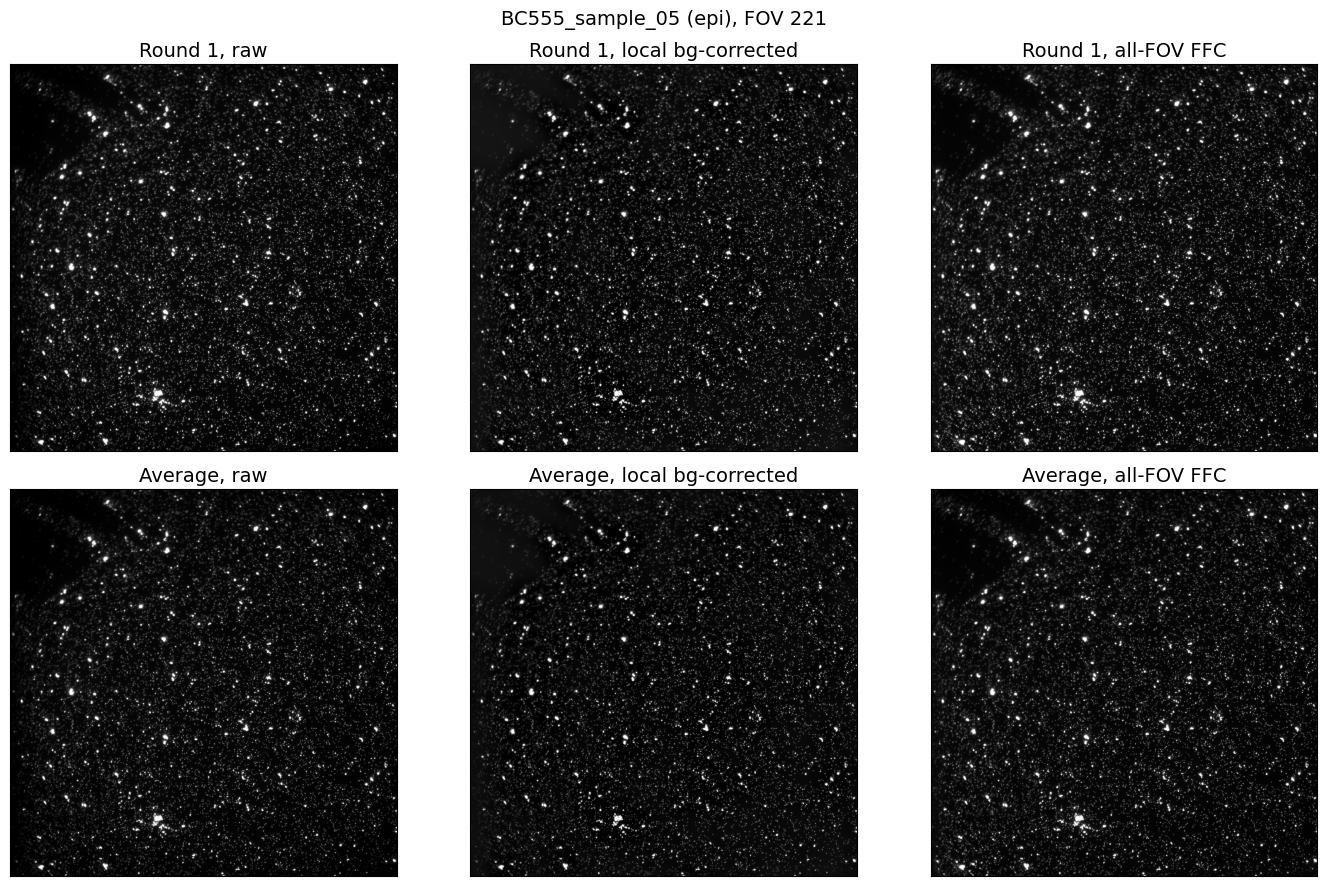

[epi] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/figures/test_bead_background_correction.raw_vs_corrected.png


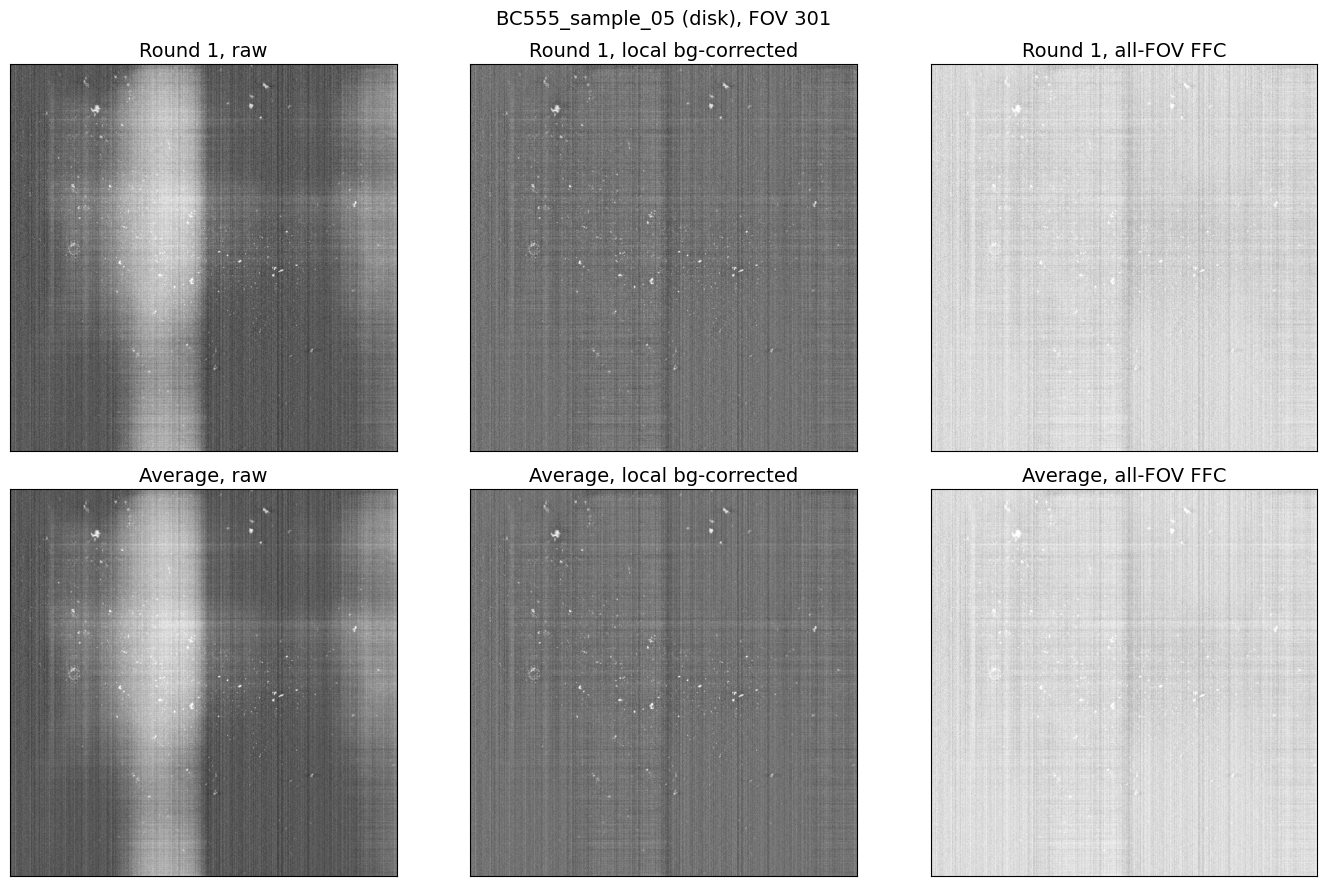

[disk] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/figures/test_bead_background_correction.raw_vs_corrected.png


In [9]:
PIPELINE_TITLES = {"raw": "raw", "bg_corrected": "local bg-corrected", "ffc_corrected": "all-FOV FFC"}

for dataset_label, R in RESULTS.items():
    vmin, vmax = np.percentile(R["pipelines"]["raw"]["round1"], [1, 99])
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    for col, name in enumerate(PIPELINE_NAMES):
        axes[0, col].imshow(R["pipelines"][name]["round1"], cmap="gray", vmin=vmin, vmax=vmax)
        axes[0, col].set_title(f"Round 1, {PIPELINE_TITLES[name]}", fontsize=PLOT_TITLE_FONTSIZE)
        axes[1, col].imshow(R["pipelines"][name]["average"], cmap="gray", vmin=vmin, vmax=vmax)
        axes[1, col].set_title(f"Average, {PIPELINE_TITLES[name]}", fontsize=PLOT_TITLE_FONTSIZE)
    for ax in axes.ravel():
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{R['dataset_geo']['sample_name']} ({dataset_label}), "
                 f"FOV {R['dataset_geo']['representative_fov']}", fontsize=PLOT_TITLE_FONTSIZE)
    fig.tight_layout()
    fig_path = R["dataset_geo"]["figures_dir"] / f"{NOTEBOOK_NAME}.raw_vs_corrected.png"
    fig.savefig(fig_path, dpi=150)
    plt.show()
    print(f"[{dataset_label}] Saved: {fig_path}")

## 9 — Does either correction recover more of the averaging benefit?

Same background-noise-std metric as `test_bead_round_averaging.ipynb`
Section 8 (background = round1-raw's own below-median pixels, same pixel
locations used for every image so the comparison is apples to apples),
computed for all three pipelines. If a background artifact was responsible
for disk's flat 0.95x result, correction should move `observed_ratio`
closer to `expected_ratio_if_independent_noise` for `disk` and leave `epi`
about where it already was.

dataset      pipeline  n_rounds_averaged  background_std_round1  background_std_average  observed_ratio  expected_ratio_if_independent_noise
    epi           raw                 10                512.246                 456.380           1.122                                3.162
    epi  bg_corrected                 10                947.842                 845.201           1.121                                3.162
    epi ffc_corrected                 10                594.207                 485.671           1.223                                3.162
   disk           raw                  2                  3.425                   3.591           0.954                                1.414
   disk  bg_corrected                  2                  3.659                   3.571           1.025                                1.414
   disk ffc_corrected                  2                  4.275                   4.163           1.027                                1.414


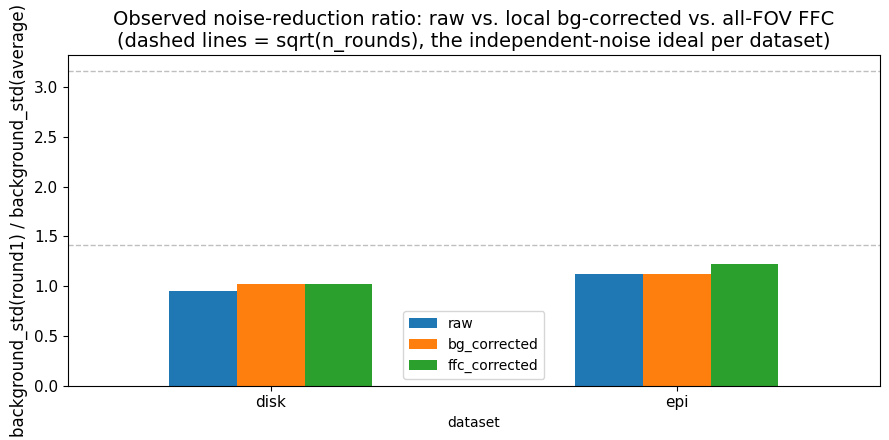

Saved: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/test_bead_background_correction_comparison/test_bead_background_correction.noise_ratio_comparison.png


In [10]:
noise_rows = []
for dataset_label, R in RESULTS.items():
    n = R["n_rounds_averaged"]
    round1_raw = R["pipelines"]["raw"]["round1"]
    bg_mask = round1_raw < np.median(round1_raw)
    for name in PIPELINE_NAMES:
        std_before = float(np.std(R["pipelines"][name]["round1"][bg_mask]))
        std_after  = float(np.std(R["pipelines"][name]["average"][bg_mask]))
        noise_rows.append({
            "dataset": dataset_label, "pipeline": name, "n_rounds_averaged": n,
            "background_std_round1": std_before, "background_std_average": std_after,
            "observed_ratio": std_before / std_after, "expected_ratio_if_independent_noise": np.sqrt(n),
        })

noise_df = pd.DataFrame(noise_rows)
print(noise_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
pivot = noise_df.pivot(index="dataset", columns="pipeline", values="observed_ratio")[list(PIPELINE_NAMES)]
pivot.plot(kind="bar", ax=ax)
for dataset_label, R in RESULTS.items():
    ax.axhline(np.sqrt(R["n_rounds_averaged"]), color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.set_ylabel("background_std(round1) / background_std(average)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title("Observed noise-reduction ratio: raw vs. local bg-corrected vs. all-FOV FFC\n"
             "(dashed lines = sqrt(n_rounds), the independent-noise ideal per dataset)",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(axis="both", labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
plt.setp(ax.get_xticklabels(), rotation=0)
fig.tight_layout()
fig_path = MERCI_DIR / "cache" / "test_bead_background_correction_comparison" / f"{NOTEBOOK_NAME}.noise_ratio_comparison.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")